In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
import tensorflow_hub as hub
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


c:\Users\jettg\miniconda3\envs\ece228\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


TensorFlow: 2.21.0
GPUs available: []


In [2]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10
SEED                = 42
EFFNET_LITE0_URL    = 'https://tfhub.dev/tensorflow/efficientnet/lite0/feature-vector/2'

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string (used as folder names too)

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


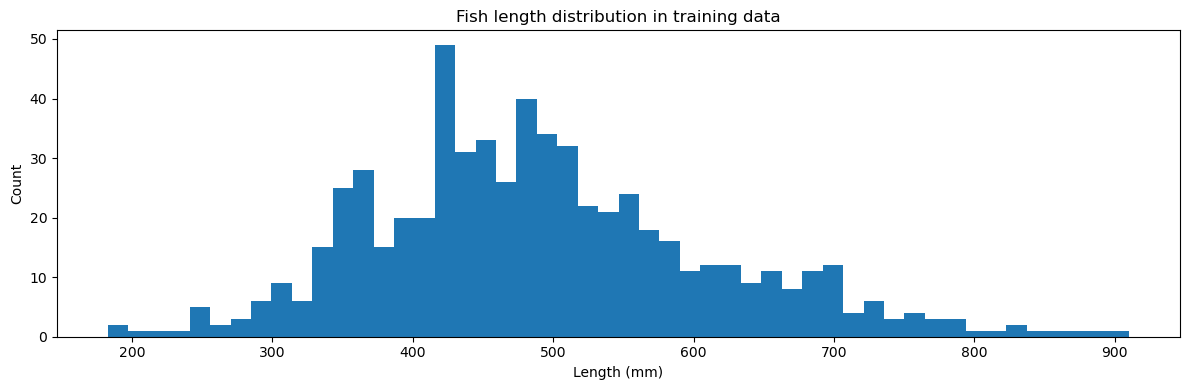

Min: 183mm, Max: 910mm, N: 623


In [4]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

In [5]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [6]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_classifier(num_classes, input_shape=(75, 200, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

classifier = build_classifier(NUM_SPECIES)
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
classifier.summary()





Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 75, 200, 3)]         0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 75, 200, 32)          896       ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 75, 200, 32)          128       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 max_pooling2d (MaxPooling2  (None, 37, 100, 32)          0         ['batch_normalization[0

## Train Classifier

Epoch 1/10


141/141 [==============================] - 15s 74ms/step - loss: 1.4640 - accuracy: 0.5789 - val_loss: 2.6891 - val_accuracy: 0.2742
Epoch 2/10
141/141 [==============================] - 10s 72ms/step - loss: 0.7548 - accuracy: 0.7920 - val_loss: 2.7650 - val_accuracy: 0.2599
Epoch 3/10
141/141 [==============================] - 10s 73ms/step - loss: 0.5229 - accuracy: 0.8557 - val_loss: 5.3402 - val_accuracy: 0.0735
Epoch 4/10
141/141 [==============================] - 10s 71ms/step - loss: 0.4214 - accuracy: 0.8780 - val_loss: 3.2688 - val_accuracy: 0.3710
Epoch 5/10
141/141 [==============================] - 10s 71ms/step - loss: 0.3530 - accuracy: 0.8989 - val_loss: 1.8650 - val_accuracy: 0.5358
Epoch 6/10
141/141 [==============================] - 10s 72ms/step - loss: 0.3068 - accuracy: 0.9109 - val_loss: 2.1605 - val_accuracy: 0.6380
Epoch 7/10
141/141 [==============================] - 10s 72ms/step - loss: 0.2795 - accuracy: 0.9132 - val_loss: 1.7835 - val_accurac

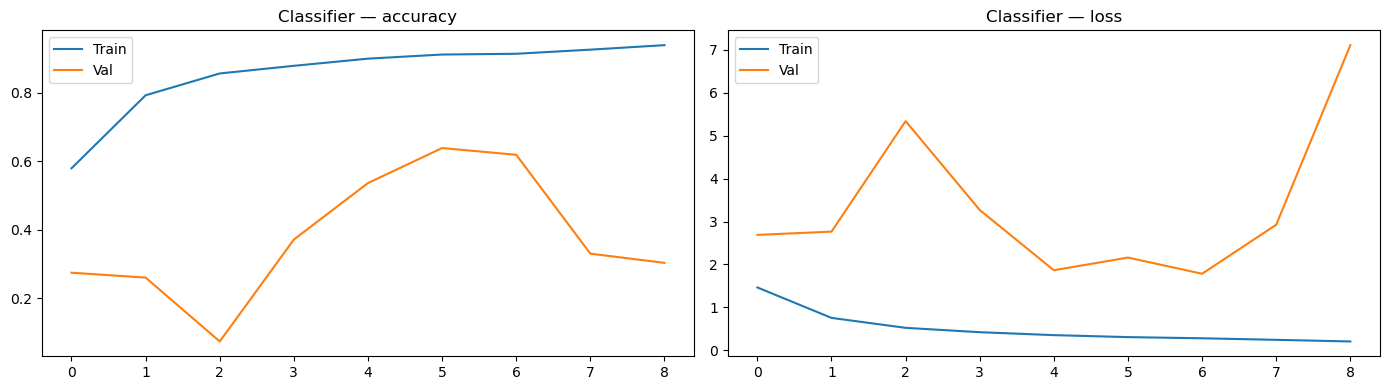

Classifier test accuracy: 62.54%


In [7]:
early_stop_cls = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

cls_history = classifier.fit(
    X_cls_train, y_cls_train_enc,
    validation_data=(X_cls_val, y_cls_val_enc),
    epochs=CLASSIFIER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_cls]
)

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(cls_history.history['accuracy'],     label='Train')
ax1.plot(cls_history.history['val_accuracy'], label='Val')
ax1.set_title('Classifier — accuracy'); ax1.legend()
ax2.plot(cls_history.history['loss'],     label='Train')
ax2.plot(cls_history.history['val_loss'], label='Val')
ax2.set_title('Classifier — loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = classifier.evaluate(X_cls_test, y_cls_test_enc, verbose=0)
print(f'Classifier test accuracy: {test_acc:.2%}')


# Size Estimator (Bins)

In [8]:
train_pkl_folds = train_folds
test_pkl_folds  = test_folds
TRAIN_FOLDS = list(range(0, 9))
VAL_FOLDS   = [9]

In [9]:
def folds_to_arrays(folds, fold_indices=None):
    """
    Unpack the listed folds into (N, 224, 224, 3) float32 images and (N,) int bin labels.
    Each fish contributes 9 image entries (one per scanner view).
    """
    if fold_indices is None:
        fold_indices = list(range(len(folds)))
    X, y = [], []
    skipped_fish = 0
    for fi in fold_indices:
        fold = folds[fi]
        for i, raw in enumerate(fold['data']):           # raw: (9, 75, 200, 3)
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped_fish += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped_fish += 1; continue

            # Each fish has 9 views — emit one example per view
            for view_idx in range(raw.shape[0]):
                img = raw[view_idx].astype(np.float32)   # (75, 200, 3)
                img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
                X.append(img_resized)
                y.append(bin_idx)

    print(f'  Loaded {len(X)} images from {len(X)//9} fish, skipped {skipped_fish} fish')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

In [10]:
print('Building train set...')
X_train, y_train = folds_to_arrays(train_pkl_folds, TRAIN_FOLDS)
print('Building val set...')
X_val,   y_val   = folds_to_arrays(train_pkl_folds, VAL_FOLDS)
print('Building test set...')
X_test,  y_test  = folds_to_arrays(test_pkl_folds)

print(f'\nTrain: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')
print(f'Train bin counts: {np.bincount(y_train, minlength=NUM_SIZE_BINS)}')
print(f'Val   bin counts: {np.bincount(y_val,   minlength=NUM_SIZE_BINS)}')
print(f'Test  bin counts: {np.bincount(y_test,  minlength=NUM_SIZE_BINS)}')

Building train set...
  Loaded 5040 images from 560 fish, skipped 1 fish
Building val set...
  Loaded 558 images from 62 fish, skipped 0 fish
Building test set...
  Loaded 639 images from 71 fish, skipped 0 fish

Train: 5040  Val: 558  Test: 639
Train bin counts: [  0   0  18  54 108 342 576 936 972 711 459 306 306 189  63]
Val   bin counts: [ 0  0  0  9  9 54 72 99 81 72 45 36 45 27  9]
Test  bin counts: [  0   0   0   0  18  18  54 126 117  90  90  54   9  45  18]


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds   = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))
test_ds  = (tf.data.Dataset.from_tensor_slices((X_test, y_test))
            .batch(BATCH_SIZE).cache().prefetch(AUTOTUNE))

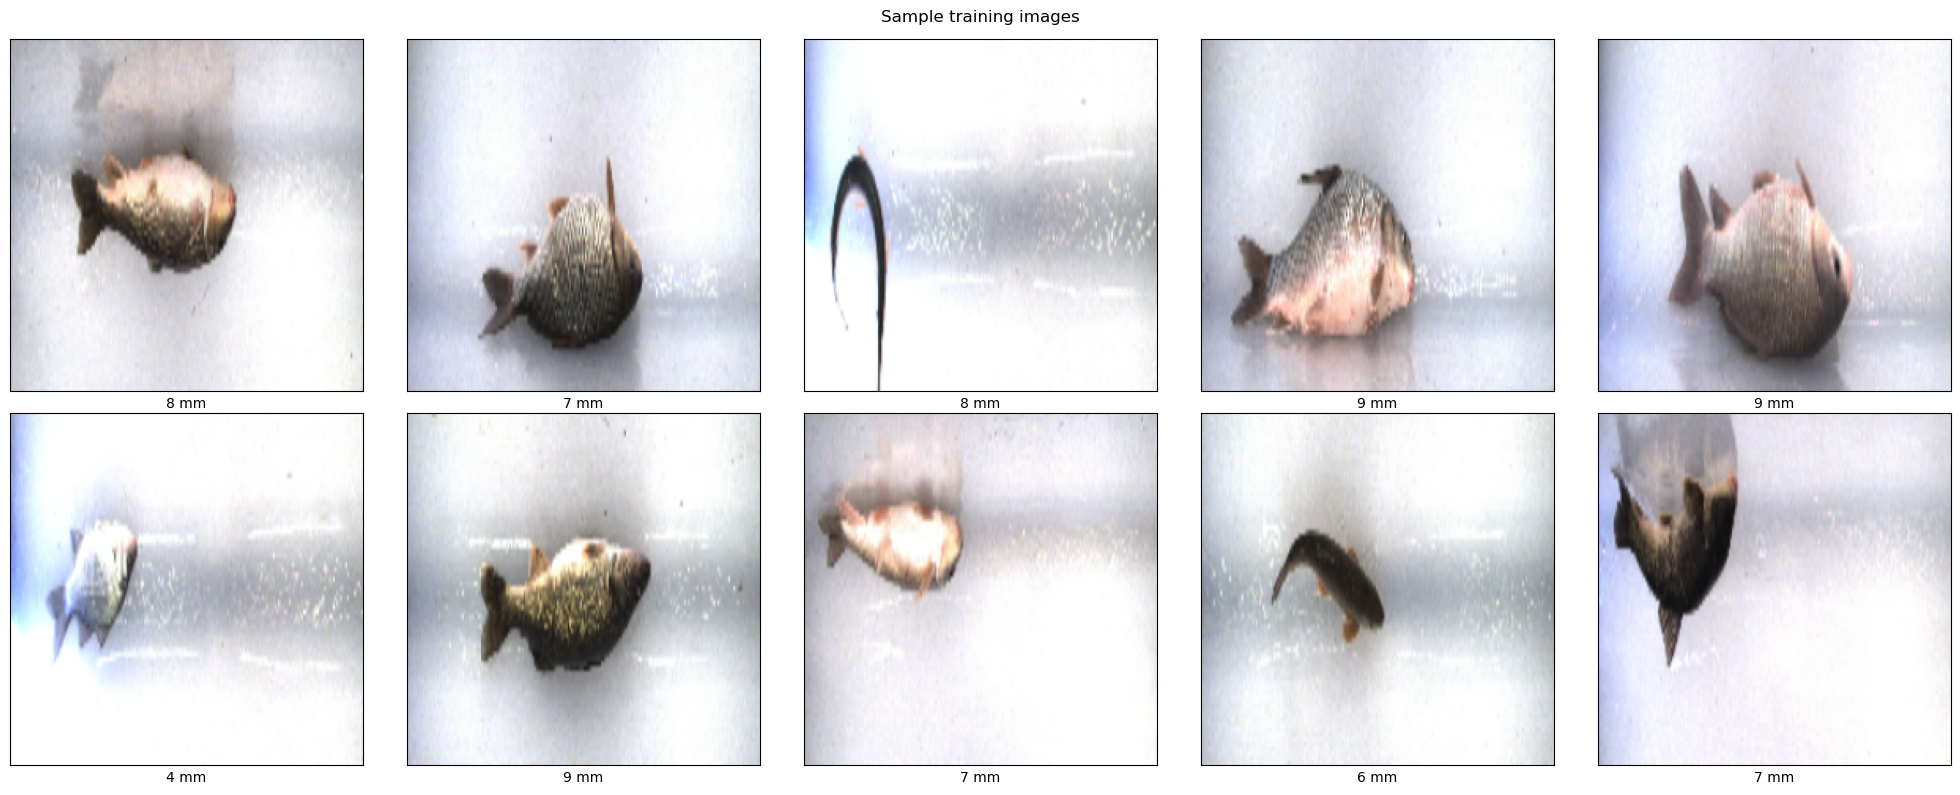

In [12]:
plt.figure(figsize=(20, 8))
for imgs, lbls in train_ds.take(1):
    for i in range(min(10, imgs.shape[0])):
        plt.subplot(2, 5, i + 1)
        plt.xticks([]); plt.yticks([]); plt.grid(False)
        plt.imshow(imgs[i].numpy().astype('uint8'))
        plt.xlabel(f'{lbls[i].numpy():.0f} mm')
plt.suptitle('Sample training images')
plt.tight_layout(); plt.show()

## Build Estimator Model

In [13]:
def build_estimator(num_classes, trainable_backbone=False):
    backbone = hub.KerasLayer(
        EFFNET_LITE0_URL,
        trainable=trainable_backbone,
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
    )
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=ESTIMATE_IMAGE_SIZE + (3,)),
        tf.keras.layers.Rescaling(1.0 / 255.0),   # [0,255] → [0,1] for Lite0
        backbone,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS, trainable_backbone=False)
estimator.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 keras_layer (KerasLayer)    (None, 1280)              3413024   
                                                                 
 dropout_1 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 15)                19215     
                                                                 
Total params: 3432239 (13.09 MB)
Trainable params: 19215 (75.06 KB)
Non-trainable params: 3413024 (13.02 MB)
_________________________________________________________________


## Train Model

In [14]:
# Class weights for bin imbalance (small/large fish are rare in Silva's data)
unique_bins = np.unique(y_train)
weights_arr = compute_class_weight('balanced', classes=unique_bins, y=y_train)
class_weights = dict(zip(unique_bins.tolist(), weights_arr.tolist()))
for c in range(NUM_SIZE_BINS):
    class_weights.setdefault(c, 1.0)
print(f'Class weights: {class_weights}')

early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

history = estimator.fit(
    train_ds,
    validation_data=val_ds,
    epochs=ESTIMATOR_EPOCHS
    # Below options not used by Silva but do improve accuracy
    #class_weight=class_weights,
    #callbacks=[early_stop],
)

Class weights: {2: 21.53846153846154, 3: 7.17948717948718, 4: 3.58974358974359, 5: 1.1336032388663968, 6: 0.6730769230769231, 7: 0.41420118343195267, 8: 0.39886039886039887, 9: 0.5452775073028238, 10: 0.8446455505279035, 11: 1.2669683257918551, 12: 1.2669683257918551, 13: 2.051282051282051, 14: 6.153846153846154, 0: 1.0, 1: 1.0}
Epoch 1/10
158/158 [==============================] - 18s 107ms/step - loss: 1.8360 - accuracy: 0.3163 - val_loss: 1.7138 - val_accuracy: 0.3405
Epoch 2/10
158/158 [==============================] - 16s 102ms/step - loss: 1.3999 - accuracy: 0.4754 - val_loss: 1.6132 - val_accuracy: 0.3889
Epoch 3/10
158/158 [==============================] - 16s 101ms/step - loss: 1.2343 - accuracy: 0.5385 - val_loss: 1.5144 - val_accuracy: 0.4337
Epoch 4/10
158/158 [==============================] - 16s 101ms/step - loss: 1.1314 - accuracy: 0.5841 - val_loss: 1.4744 - val_accuracy: 0.4785
Epoch 5/10
158/158 [==============================] - 16s 103ms/step - loss: 1.0585 - acc

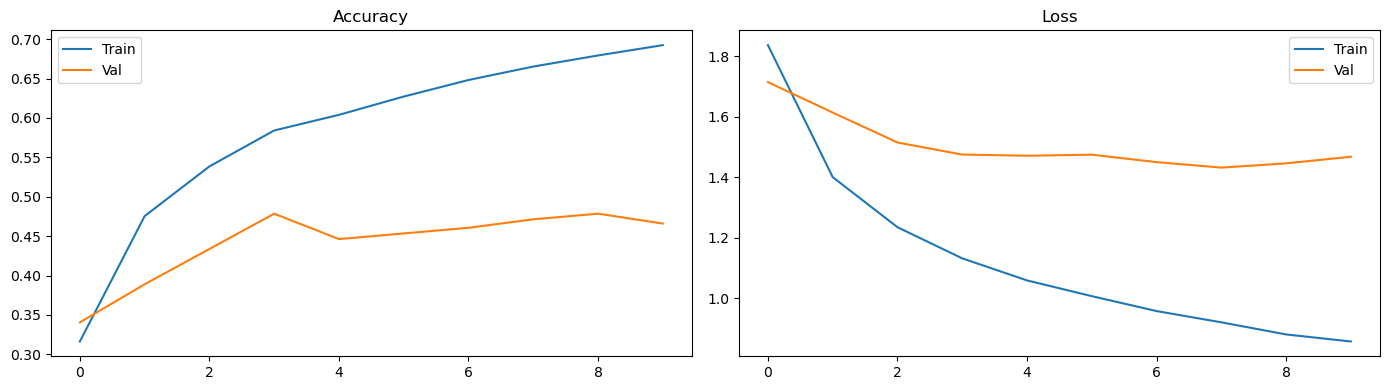

Train  — loss: 0.7721, accuracy: 74.31%
Val    — loss: 1.4673, accuracy: 46.59%
Test   — loss: 1.5068, accuracy: 44.60%


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(train_ds, 'Train'), (val_ds, 'Val'), (test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')

## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution. **`alpha`** is the weight on the **estimator**; `(1 - alpha)` is the weight on the species-informed prior (`SPECIES_SIZE_PRIOR` from `configs/species_priors_by_code.yaml`).

- **Baselines:** `α=1.0` (estimator only), `α=0.0` (prior only)
- **Sweep:** test many `α` values on the aligned test set and pick the best for the confusion matrix

In [16]:
# ── Biological priors: P(size bin | species) ───────────────────────────────────
from pathlib import Path

PRIORS_BY_CODE_PATH = Path('../configs/species_priors_by_code.yaml')


def load_species_priors_by_code(path):
    """Load mean/min/max priors from simple YAML (no PyYAML dependency)."""
    priors = {}
    species = None
    for raw in Path(path).read_text().splitlines():
        line = raw.split('#', 1)[0].strip()
        if not line:
            continue
        if line.endswith(':') and ' ' not in line.rstrip(':'):
            species = line[:-1].strip()
            priors[species] = {}
            continue
        if species is None:
            continue
        key, _, val = line.partition(':')
        if val.strip():
            priors[species][key.strip()] = float(val.strip())
    return priors


def build_prior_matrix(species_classes, bin_labels, priors_by_code, sigma_scale=0.25):
    """Truncated Gaussian over bin centers; uniform row if species stats missing."""
    bin_centers = np.array([float(label) for label in bin_labels], dtype=np.float32)
    num_species = len(species_classes)
    num_bins = len(bin_labels)
    matrix = np.zeros((num_species, num_bins), dtype=np.float32)
    uniform = np.full(num_bins, 1.0 / num_bins, dtype=np.float32)

    for i, code in enumerate(species_classes):
        stats = priors_by_code.get(code)
        if not stats:
            matrix[i] = uniform
            continue
        mu = stats['mean_length_cm']
        lo = stats['min_length_cm']
        hi = stats['max_length_cm']
        sigma = max((hi - lo) * sigma_scale, 1.0)
        w = np.exp(-0.5 * ((bin_centers - mu) / sigma) ** 2)
        w *= (bin_centers >= lo) & (bin_centers <= hi)
        matrix[i] = w / w.sum() if w.sum() > 0 else uniform

    return matrix


priors_by_code = load_species_priors_by_code(PRIORS_BY_CODE_PATH)
SPECIES_SIZE_PRIOR = build_prior_matrix(species_le.classes_, BIN_LABELS, priors_by_code)

assert SPECIES_SIZE_PRIOR.shape == (NUM_SPECIES, NUM_SIZE_BINS)
assert np.allclose(SPECIES_SIZE_PRIOR.sum(axis=1), 1.0)

mapped = sum(1 for c in species_le.classes_ if c in priors_by_code)
print(
    f'Biological priors: {mapped}/{NUM_SPECIES} species with stats, '
    f'{NUM_SPECIES - mapped} uniform fallback rows'
)


Biological priors: 22/22 species with stats, 0 uniform fallback rows


In [17]:
def predict_combined(images_224, images_75_200, alpha=0.5):
    """
    Predict size bins by blending the size estimator and species classifier outputs.

    Parameters
    ----------
    images_224    : (N, 224, 224, 3) float32 — input for the size estimator
    images_75_200 : (N,  75, 200, 3) float32 — input for the species classifier
    alpha         : float in [0, 1] — weight on the estimator (1 = estimator only, 0 = prior only)

    Returns
    -------
    pred_bins : (N,) int array of predicted size-bin indices
    """
    # Size estimator: P(bin | image)
    est_probs = estimator.predict(images_224, verbose=0)          # (N, NUM_SIZE_BINS)

    # Classifier: P(species | image)
    species_probs = classifier.predict(images_75_200, verbose=0)  # (N, NUM_SPECIES)

    # Species-informed size prior: P(bin) = sum_s P(species=s|image) * P(bin|species=s)
    prior_scores = species_probs @ SPECIES_SIZE_PRIOR              # (N, NUM_SIZE_BINS)

    combined  = alpha * est_probs + (1 - alpha) * prior_scores
    pred_bins = np.argmax(combined, axis=1)
    return pred_bins


# ── Build the 75x200 test set (needed by the classifier) ─────────────────────
# Note: reshape to (75, 200, 3) explicitly — (-1, 200, 3) would incorrectly
# collapse all rows across the batch into a single dimension.
X_test_75_list = []
X_est_test_list = []
y_est_test_list = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue

        # One 75x200 view (view 0) per fish for the classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image per fish for the estimator
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy() / 255.0
        X_est_test_list.append(img_224)

        y_est_test_list.append(bin_idx)

X_test_75       = np.array(X_test_75_list,  dtype=np.float32)
X_est_test_norm = np.array(X_est_test_list, dtype=np.float32)
y_est_test_aligned = np.array(y_est_test_list, dtype=np.int32)
print(f'Aligned test set: {len(y_est_test_aligned)} fish')


Aligned test set: 71 fish


Alpha baselines (aligned test set):
  Estimator only (α=1.0)       2.82%
  Prior only (α=0.0)           12.68%
  Equal blend (α=0.5)          11.27%

Best α = 0.25  →  accuracy 16.90%


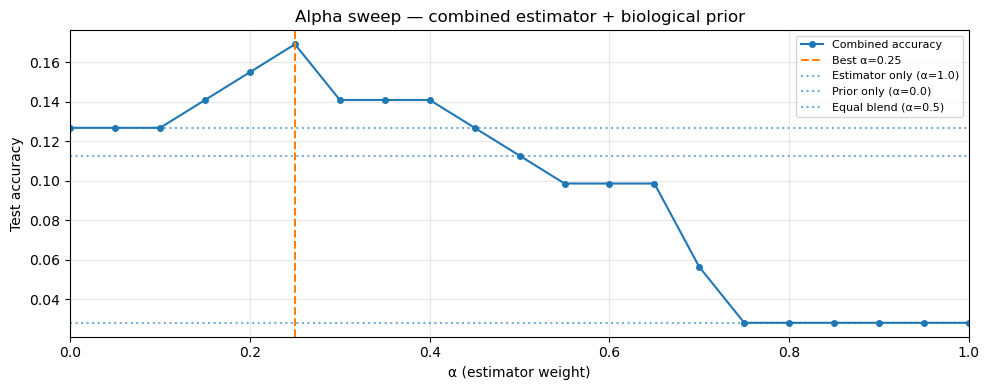

In [18]:
# ── Alpha baselines & sweep (single predict pass, then blend) ─────────────────
y_true = y_est_test_aligned

est_probs     = estimator.predict(X_est_test_norm, verbose=0)       # (N, NUM_SIZE_BINS)
species_probs = classifier.predict(X_test_75, verbose=0)            # (N, NUM_SPECIES)
prior_scores  = species_probs @ SPECIES_SIZE_PRIOR                    # (N, NUM_SIZE_BINS)


def blend_and_predict(alpha):
    combined = alpha * est_probs + (1.0 - alpha) * prior_scores
    return np.argmax(combined, axis=1)


def bin_accuracy(preds):
    return np.mean(preds == y_true)


# ── Baselines ─────────────────────────────────────────────────────────────────
ALPHA_BASELINES = [
    (1.0, 'Estimator only (α=1.0)'),
    (0.0, 'Prior only (α=0.0)'),
    (0.5, 'Equal blend (α=0.5)'),
]

print('Alpha baselines (aligned test set):')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    print(f'  {label:<28} {acc:.2%}')

# ── Sweep ─────────────────────────────────────────────────────────────────────
ALPHAS = np.round(np.arange(0.0, 1.01, 0.05), 2)
sweep_acc = [bin_accuracy(blend_and_predict(a)) for a in ALPHAS]

best_idx   = int(np.argmax(sweep_acc))
BEST_ALPHA = float(ALPHAS[best_idx])
best_acc   = sweep_acc[best_idx]

print(f'\nBest α = {BEST_ALPHA:.2f}  →  accuracy {best_acc:.2%}')

# ── Plot sweep ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ALPHAS, sweep_acc, marker='o', markersize=4, label='Combined accuracy')
ax.axvline(BEST_ALPHA, color='C1', ls='--', label=f'Best α={BEST_ALPHA:.2f}')
for alpha, label in ALPHA_BASELINES:
    acc = bin_accuracy(blend_and_predict(alpha))
    ax.axhline(acc, ls=':', alpha=0.6, label=label)
ax.set_xlabel('α (estimator weight)')
ax.set_ylabel('Test accuracy')
ax.set_title('Alpha sweep — combined estimator + biological prior')
ax.set_xlim(0, 1)
ax.legend(loc='best', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Predictions at best α for confusion matrix below
pred_bins = blend_and_predict(BEST_ALPHA)


### Confusion matrix — combined pipeline (best α from sweep)

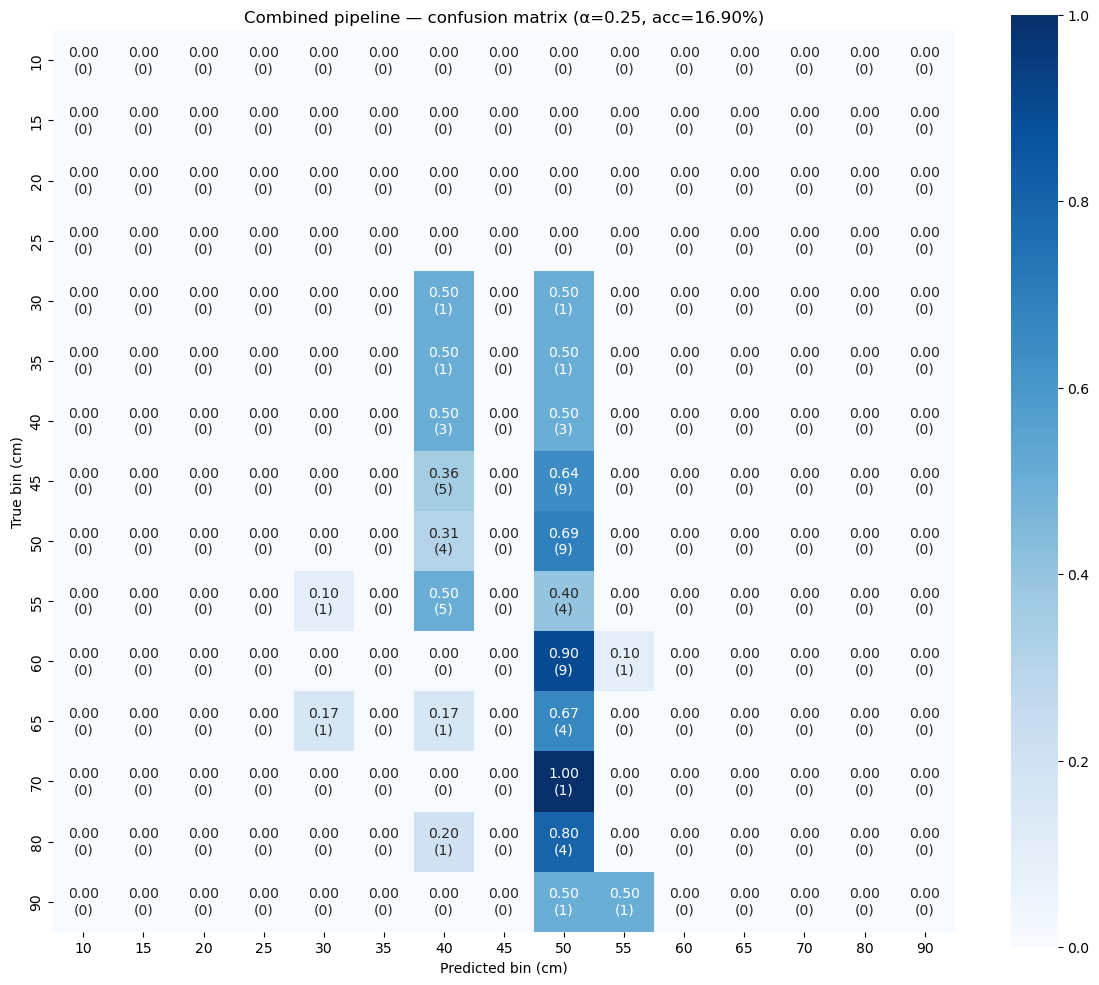

In [19]:
cm      = confusion_matrix(y_est_test_aligned, pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title(f'Combined pipeline — confusion matrix (α={BEST_ALPHA:.2f}, acc={best_acc:.2%})')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()
